In [1]:
import coiled

cluster = coiled.Cluster(
    name="demo-region",
    n_workers=1,
    region="us-west-2",
    worker_vm_types="r8g.2xlarge",
    scheduler_vm_types="r8g.2xlarge",
)

client = cluster.get_client()

[2026-01-08 15:33:51,290][INFO    ][coiled] Using existing cluster: 'demo-region (id: 1368095)'
[2026-01-08 15:33:51,291][INFO    ][coiled] Attaching to existing cluster (name: demo-region, https://cloud.coiled.io/clusters/1368095 )


In [2]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from ibicus.debias import QuantileMapping

In [3]:
from srm import downscaling_utils

# Get data

In [4]:
RUN_PARAMETERS = {
    "OBS": "ERA5",
    "GCM": "CESM2-WACCM",
    "TRAIN_PERIOD_START": 1978 + 5,
    "TRAIN_PERIOD_END": 2014,
    "PREDICT_PERIOD_START": 2015,
    "PREDICT_PERIOD_END": 2100,
    "VAR": "tas",
}

In [5]:
ssp245 = downscaling_utils.get_experiment(
    gcm=RUN_PARAMETERS["GCM"], scenario="SSP245", var=RUN_PARAMETERS["VAR"]
)
ssp245 = ssp245.isel(ensemble_member=0)

model_historical = downscaling_utils.get_experiment(
    gcm=RUN_PARAMETERS["GCM"], scenario="Historical", var=RUN_PARAMETERS["VAR"]
)

In [6]:
era5 = downscaling_utils.get_obs(var=RUN_PARAMETERS["VAR"])

In [7]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

### Subset data to demo region (South Africa)

In [8]:
era5_south_africa_bounds = downscaling_utils.subset_space(
    era5, coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
)

model_historical_south_africa_bounds = downscaling_utils.subset_space(
    model_historical, coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
)

ssp245_south_africa_bounds = downscaling_utils.subset_space(
    ssp245, coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
)

In [9]:
dict_all = {
    "ssp245": ssp245_south_africa_bounds,
    "model_hist": model_historical_south_africa_bounds,
    "era5": era5_south_africa_bounds,
}

# Preprocess data

### Calculate coarse version of high-res observational dataset
(this is an imprecise linear interpolation -- need to change to area averaging)

In [46]:
dict_all["era5_coarse"] = downscaling_utils.interpolate_to_coarse_grid(
    da_fine_to_coarsen=dict_all["era5"], da_coarse_grid=dict_all["ssp245"]
)

### Concatenate historical and future scenario
This is necessary for calculating the 9-year rolling average when detrending

In [47]:
dict_all["historical_ssp"] = xr.concat(
    [
        dict_all["model_hist"].where(
            dict_all["model_hist"]["time.year"] <= RUN_PARAMETERS["TRAIN_PERIOD_END"],
            drop=True,
        ),
        dict_all["ssp245"].where(
            dict_all["ssp245"]["time.year"] > RUN_PARAMETERS["TRAIN_PERIOD_END"],
            drop=True,
        ),
    ],
    dim="time",
)

### Detrend future scenario data

In [48]:
da_baseline_clim = downscaling_utils.calculate_baseline_climatology(
    da_baseline=dict_all["model_hist"],
    baseline_period_start=RUN_PARAMETERS["PREDICT_PERIOD_START"],
    baseline_period_end=RUN_PARAMETERS["PREDICT_PERIOD_END"],
)

ssp_detrended, ssp_trend_on_daily_timestep = downscaling_utils.detrend(
    da=dict_all["historical_ssp"].drop_vars("spatial_ref", errors="ignore"),
    da_baseline_clim=da_baseline_clim,
)

In [49]:
dict_all["ssp245_detrended"] = ssp_detrended
dict_all["ssp245_trend"] = ssp_trend_on_daily_timestep

### Subset to years for training and predicting

In [50]:
for key, ds in dict_all.items():
    if "era" in key:
        time_period = "train"
    if "ssp245" in key:
        time_period = "predict"
    if "model_hist" in key:
        time_period = "train"

    dict_all[key] = downscaling_utils.subset_time(
        da=ds, run_parameters=RUN_PARAMETERS, time_period=time_period
    )

### Make plots looking at monthly trends

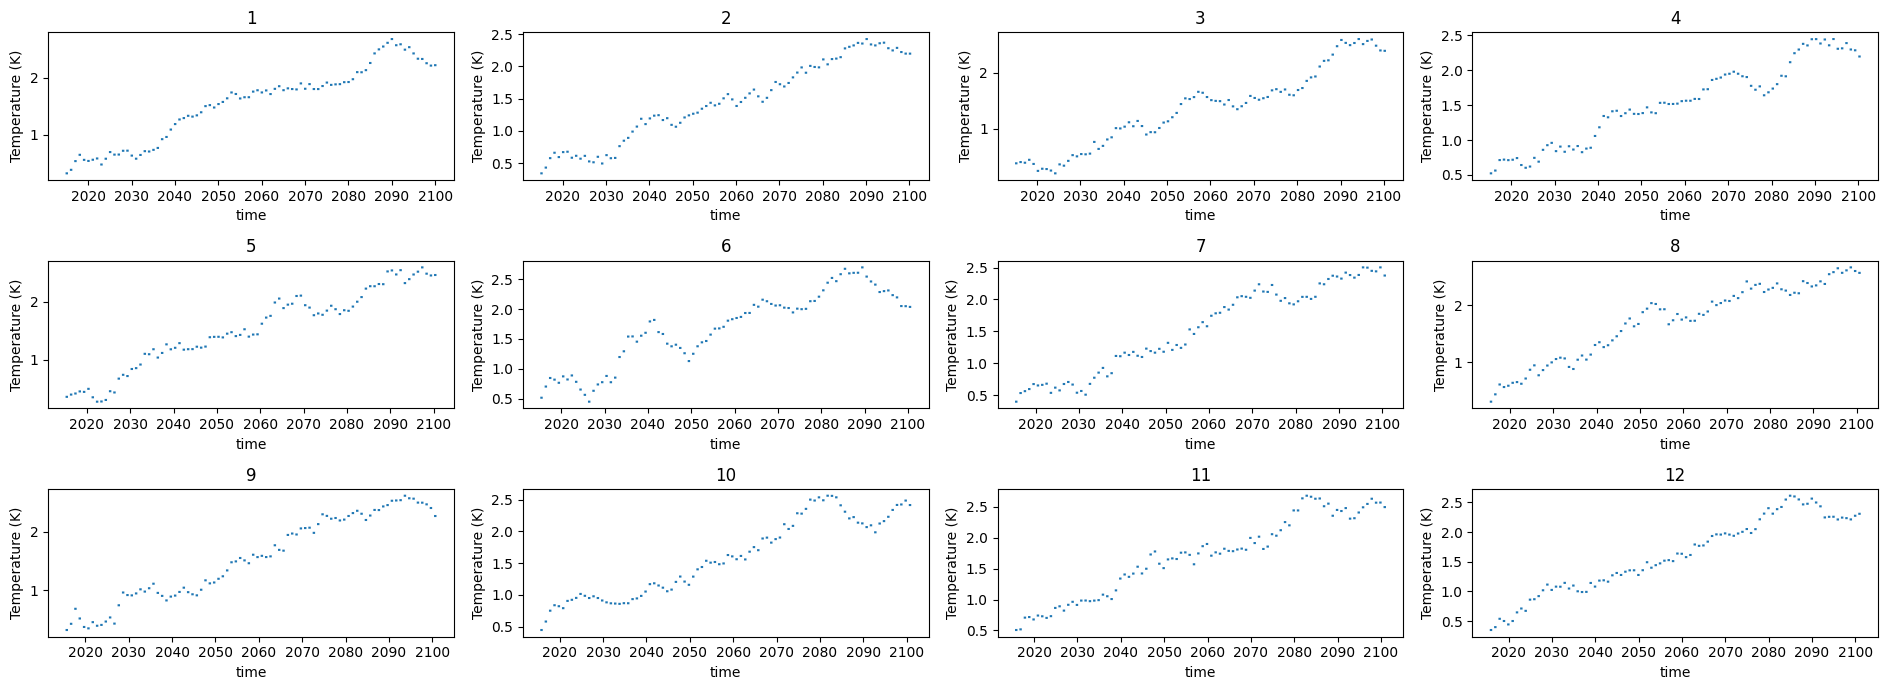

In [51]:
scenario = "ssp245"

plt.figure(figsize=(19, 7))
for m in np.arange(1, 13):
    plt.subplot(3, 4, m)
    (
        dict_all[scenario + "_trend"][:, 0, 0].where(
            dict_all[scenario + "_trend"]["time.month"] == m
        )
    ).plot()
    plt.title(m)
    plt.ylabel("Temperature (K)")
plt.tight_layout()

/Users/clairezarakas/Documents/science/carbonplan-srm/.venv/lib/python3.13/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 102.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Users/clairezarakas/Documents/science/carbonplan-srm/.venv/lib/python3.13/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 102.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Users/clairezarakas/Documents/science/carbonplan-srm/.venv/lib/python3.13/site-packages/d

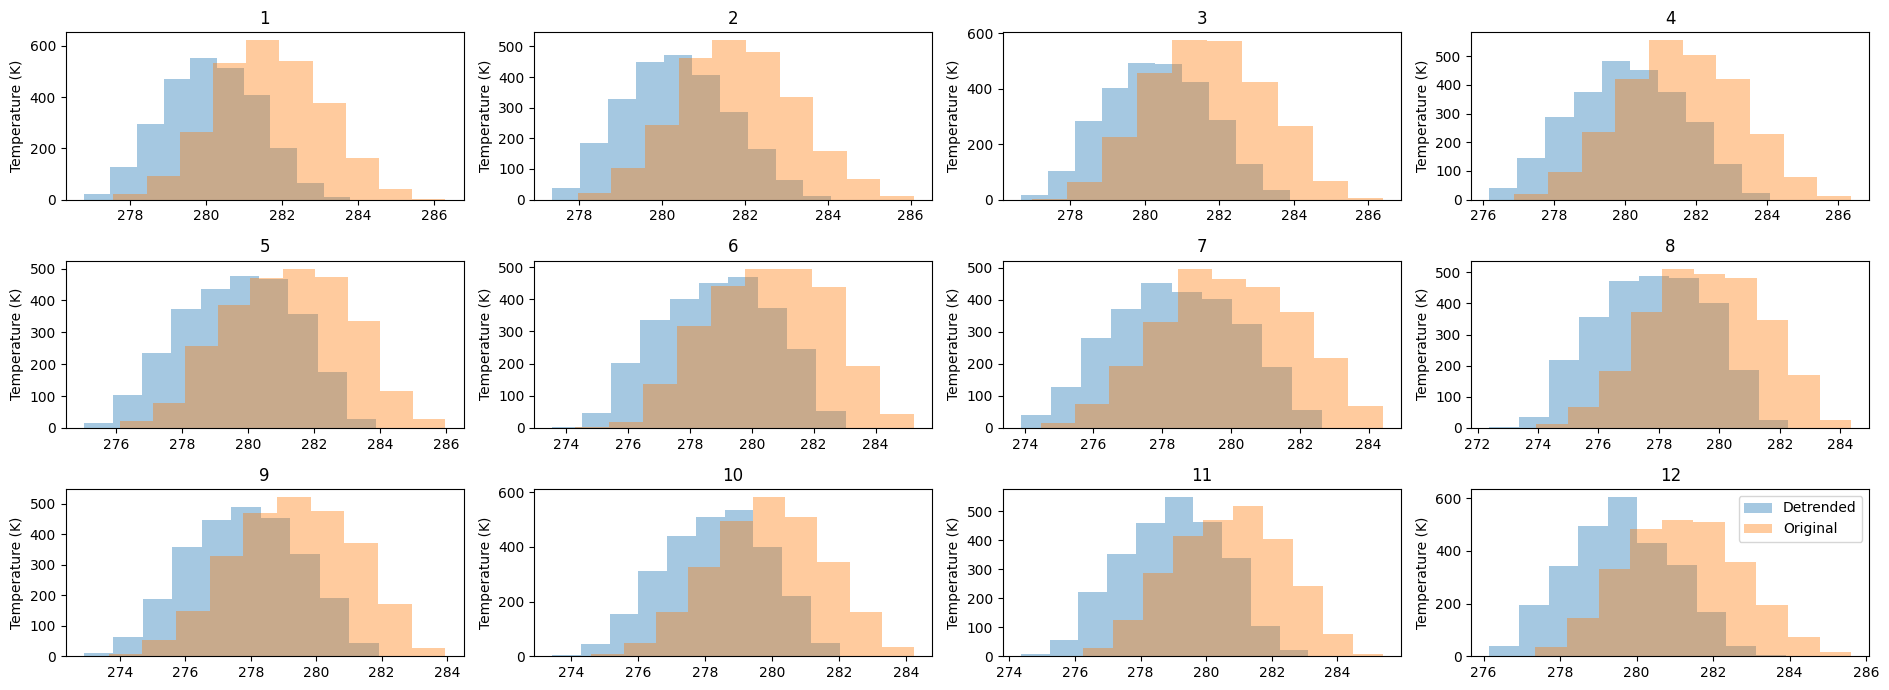

In [52]:
plt.figure(figsize=(19, 7))
for m in np.arange(1, 13):
    plt.subplot(3, 4, m)
    plt.hist(
        dict_all[scenario + "_detrended"][:, 0, 0].where(
            dict_all[scenario + "_detrended"]["time.month"] == m
        ),
        alpha=0.4,
        label="Detrended",
    )
    plt.hist(
        dict_all[scenario][:, 0, 0].where(dict_all[scenario]["time.month"] == m),
        alpha=0.4,
        label="Original",
    )
    plt.title(m)
    plt.ylabel("Temperature (K)")
plt.tight_layout()
plt.legend()

/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_63428/4205898303.py:6: DeprecationWarning: Reductions are applied along the rolling dimension(s) '['time']'. Passing the 'dim' kwarg to reduction operations has no effect.
  .mean(dim="time")
/Users/clairezarakas/Documents/science/carbonplan-srm/.venv/lib/python3.13/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 102.27 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_63428/4205898303.py:9: DeprecationWarning: Reductions are applied along the rolling dimension(s) '['time']'. Passing the 'dim' kwarg to reduction operations has no effect.
  (dict_all[scenario][:, 0, 0].rolling(time=365 * 5).mean(dim="

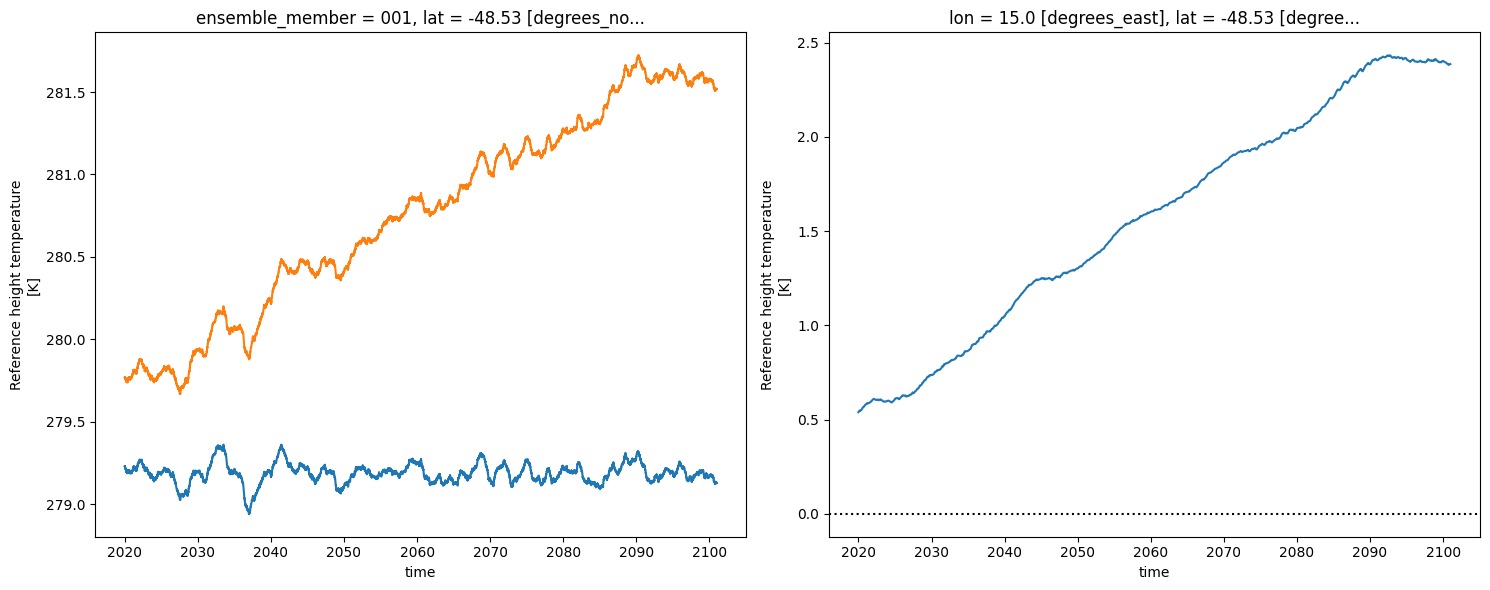

In [53]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
(
    dict_all[scenario + "_detrended"][:, 0, 0]
    .rolling(time=365 * 5)
    .mean(dim="time")
    .plot()
)
(dict_all[scenario][:, 0, 0].rolling(time=365 * 5).mean(dim="time").plot())
plt.subplot(1, 2, 2)
(dict_all[scenario + "_trend"][:, 0, 0].rolling(time=365 * 5).mean(dim="time").plot())
plt.axhline(y=0, linestyle=":", color="k")
plt.tight_layout()

# Do bias correction

In [54]:
debiaser_v1 = QuantileMapping.from_variable(
    variable="tas", mapping_type="parametric", detrending="no_detrending"
)
debiaser_v2 = QuantileMapping.from_variable(
    variable="tas", mapping_type="parametric", detrending="additive"
)

tas_cm_hist_debiased_v1 = debiaser_v1.apply(
    obs=dict_all["era5_coarse"].values,
    cm_hist=dict_all["model_hist"].values,
    cm_future=dict_all["ssp245"].values,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
)

tas_cm_hist_debiased_v2 = debiaser_v2.apply(
    obs=dict_all["era5_coarse"].values,
    cm_hist=dict_all["model_hist"].values,
    cm_future=dict_all["ssp245"].values,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
)

tas_cm_hist_debiased_v3_anoms = debiaser_v1.apply(
    obs=dict_all["era5_coarse"].values,
    cm_hist=dict_all["model_hist"].values,
    cm_future=dict_all["ssp245_detrended"].values,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
)

tas_cm_hist_debiased_v3 = tas_cm_hist_debiased_v3_anoms + dict_all["ssp245_trend"]

100%|██████████| 620/620 [00:00<00:00, 909.28it/s]
/Users/clairezarakas/Documents/science/carbonplan-srm/.venv/lib/python3.13/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 102.27 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
100%|██████████| 620/620 [00:00<00:00, 1012.60it/s]


In [55]:
tas_cm_hist_debiased_v1 = xr.DataArray(
    data=tas_cm_hist_debiased_v1,
    coords={
        "lat": dict_all["ssp245"]["lat"],
        "lon": dict_all["ssp245"]["lon"],
        "time": dict_all["ssp245"]["time"],
    },
    dims=["time", "lat", "lon"],
)

tas_cm_hist_debiased_v2 = xr.DataArray(
    data=tas_cm_hist_debiased_v2,
    coords={
        "lat": dict_all["ssp245"]["lat"],
        "lon": dict_all["ssp245"]["lon"],
        "time": dict_all["ssp245"]["time"],
    },
    dims=["time", "lat", "lon"],
)

tas_cm_hist_debiased_v3 = xr.DataArray(
    data=tas_cm_hist_debiased_v3,
    coords={
        "lat": dict_all["ssp245"]["lat"],
        "lon": dict_all["ssp245"]["lon"],
        "time": dict_all["ssp245"]["time"],
    },
    dims=["time", "lat", "lon"],
)

### Plots looking at differences between bias correction choices

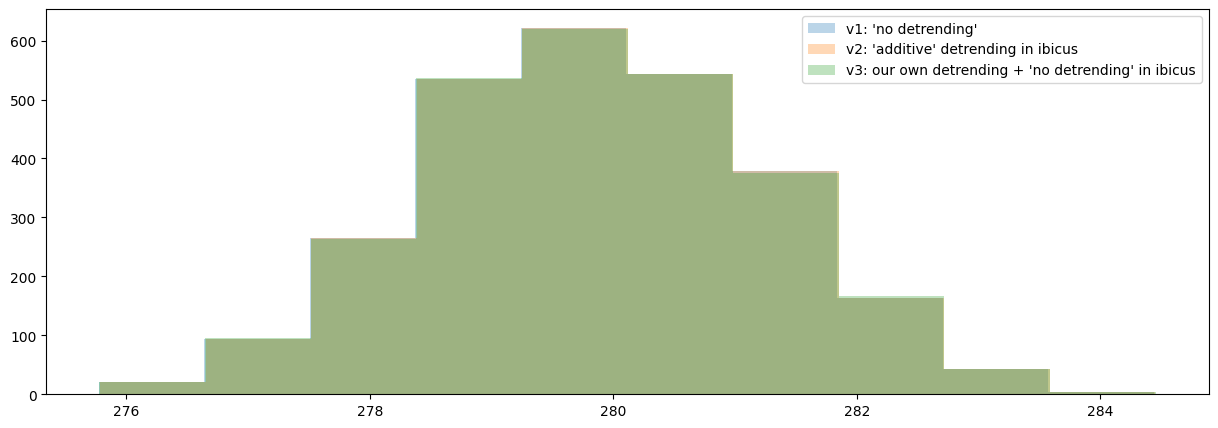

In [56]:
plt.figure(figsize=(15, 5))
plt.hist(
    tas_cm_hist_debiased_v1.where(tas_cm_hist_debiased_v1["time.month"] == 1)[:, 0, 0],
    alpha=0.3,
    label="v1: 'no detrending'",
)
plt.hist(
    tas_cm_hist_debiased_v2.where(tas_cm_hist_debiased_v2["time.month"] == 1)[:, 0, 0],
    alpha=0.3,
    label="v2: 'additive' detrending in ibicus",
)
plt.hist(
    tas_cm_hist_debiased_v3.where(tas_cm_hist_debiased_v3["time.month"] == 1)[:, 0, 0],
    alpha=0.3,
    label="v3: our own detrending + 'no detrending' in ibicus",
)
plt.legend()

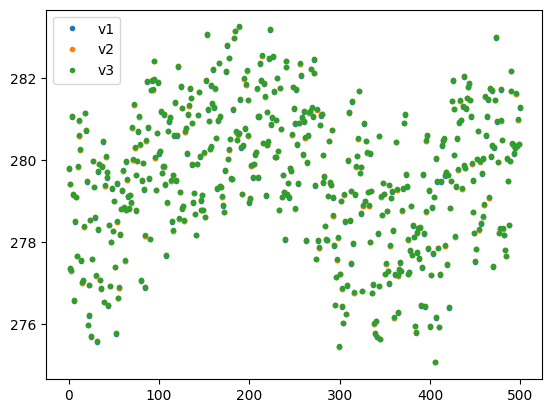

In [57]:
plt.plot(tas_cm_hist_debiased_v1[-500:, 0, 0], ".", label="v1")
plt.plot(tas_cm_hist_debiased_v2[-500:, 0, 0], ".", label="v2")
plt.plot(tas_cm_hist_debiased_v3[-500:, 0, 0], ".", label="v3")
plt.legend()

Text(0, 0.5, 'Difference from v1 (K)')

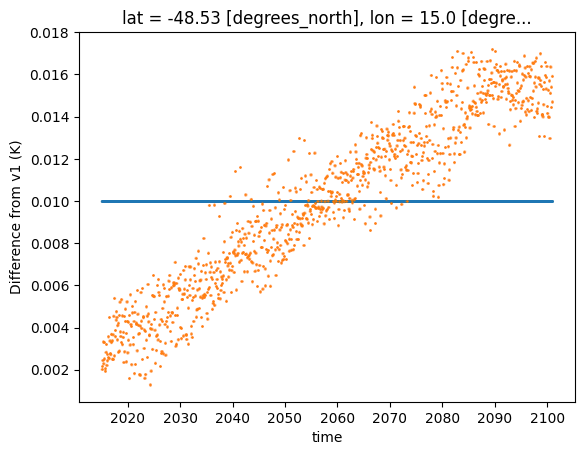

In [58]:
(tas_cm_hist_debiased_v2[:, 0, 0] - tas_cm_hist_debiased_v1[:, 0, 0]).plot(
    marker=".", linewidth=0, alpha=0.1, markersize=1
)
(tas_cm_hist_debiased_v3[:, 0, 0] - tas_cm_hist_debiased_v1[:, 0, 0]).plot(
    marker=".", linewidth=0, alpha=0.1, markersize=1
)
plt.ylabel("Difference from v1 (K)")